In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/dataset_financier_clean.csv")
df

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence_freq,banque_freq,lieu_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,0.323,0.238,0.266
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,0.323,0.260,0.251
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,0.342,0.260,0.266
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,0.323,0.260,0.251
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,0.323,0.251,0.266
...,...,...,...,...,...,...,...,...,...,...
995,45783.495607,27491.051668,3061.984415,1514.228791,3.340455,10283.863134,48249.121062,0.323,0.251,0.266
996,76965.297903,19814.351185,3206.202032,461.094090,1.068210,5123.367899,38937.469425,0.342,0.251,0.240
997,59612.642919,13826.877441,2006.591540,1339.851098,2.388452,2480.285288,34553.303006,0.335,0.238,0.243
998,41432.315153,18858.531252,3267.341134,2321.689078,9.492812,10892.386159,50680.692790,0.342,0.260,0.243


In [3]:
# version de torch et cuda
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1+cu126
CUDA available: True


In [4]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
# separer X et yy
X = df.drop("depenses", axis=1)
y = df["depenses"]

In [6]:
y

0       546.096221
1      1069.807495
2      1293.197233
3      2443.843829
4      1778.276562
          ...     
995    1514.228791
996     461.094090
997    1339.851098
998    2321.689078
999    1680.323946
Name: depenses, Length: 1000, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# standardiser
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# importation des librairies
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [10]:
# Important: PyTorch fonctionne mieux avec float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

In [11]:
# transformation des array en tenseurs avec pytorch
import torch
X_train_tensor = torch.from_numpy(X_train).to(device)
y_train_tensor = torch.from_numpy(y_train.values).to(device)
X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test.values).to(device)


In [12]:
# nous allons créer des DataLoaders afin de permettre à nos modèles d'apprendre sur nos données par batch
# Créer des DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [13]:
# validation pendant le training , ensuite nous allons créer des data-loaders pour chacun
# La validation représentera (20% du train)
val_size = int(0.2 * len(X_train_tensor))
train_size = len(X_train_tensor) - val_size

train_dataset_split, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

# création des DataLoaders pour chaque sous-ensemble
train_loader = DataLoader(train_dataset_split, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [14]:
# Définir le modèle
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super(RegressionNet, self).__init__()
        
        self.layer1 = nn.Linear(input_dim, 32) # la première couche prends en input le nombre de colonne du dataset, et envoir 32 neuronnes a la prochaine couches
        self.dropout1 = nn.Dropout(0.2)
        self.layer2 = nn.Linear(32, 16)
        self.dropout2 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout1(x)
        x = self.relu(self.layer2(x))
        x = self.dropout2(x)
        x = self.relu(self.layer3(x))
        x = self.output(x)
        return x

# Créer le modèle
input_dim = X_train.shape[1]
model = RegressionNet(input_dim).to(device) # on passe le modèle au gpu

# Afficher le résumé du modèle
print(model)
print(f"\nNombre total de paramètres: {sum(p.numel() for p in model.parameters())}")
print(f"Paramètres entraînables: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

RegressionNet(
  (layer1): Linear(in_features=9, out_features=32, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (layer3): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)

Nombre total de paramètres: 993
Paramètres entraînables: 993


In [15]:
# Définir le loss et l'optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [16]:
# nous allons définir une sorte de Scheduler pour réduire le learning rate afin de simuler le comportement de 
# la fonction reduceLRonPlateau comme avec tensorflow
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=10, 
    min_lr=0.00001
)

In [17]:
# Fonction d'entraînement
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        # nettoyer la mémoire, retirer les gradiants après chaque itération
        optimizer.zero_grad()
        # BackPropagation
        loss.backward()
        # update des weights
        optimizer.step()
        # somme de toutes les losses totales des batches
        train_loss += loss.item() * batch_X.size(0)
    
    return train_loss / len(train_loader.dataset)

In [18]:
# Fonction de validation
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    # torch no grad (le modèle est déja pret, je veux juste teste, pas de gradiant)
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    
    return val_loss / len(val_loader.dataset)

In [19]:
# Early Stopping, on veut arreter l'entrainement lorsque le modèle ne s'améliore plus
""" a chaque epoch, on va calculer un validation loss et comparer"""
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0 # il va Compter le nombre d'epochs sans amélioration
        self.best_loss = None # Stocke le meilleure loss rencontré
        self.early_stop = False # Devient True quand on doit arrêter l'entraînement
        self.best_model_state = None # Sauvegarde les meilleurs poids du modèle
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            # a la premiere itération, On initialise best_loss et on sauvegarde les poids du modèle.
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1 #Si le loss n’a pas baissé d’au moins min_delta, on augmente le compteur
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f'Early stopping triggered. Restoring best model weights.')
                model.load_state_dict(self.best_model_state)
        else:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
            self.counter = 0

In [20]:
# Entraînement complet
num_epochs = 300
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': []
}

early_stopping = EarlyStopping(patience=30, verbose=True)
# best_val_loss est initialisé à une valeur infiniment grande au début de l’entraînement 
# inf = infinity (infini positif)
best_val_loss = float('inf')

print("Début de l'entraînement...")
print("="*60)

for epoch in range(num_epochs):
    # Entraînement
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss = validate_epoch(model, val_loader, criterion, device)
    
    # Enregistrer l'historique
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, 'best_model.pth')
        print(f'Epoch {epoch+1}: val_loss improved to {val_loss:.4f}, saving model')
    
    # Affichage
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, '
              f'Val Loss: {val_loss:.4f}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    # Early stopping
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("="*60)
print("Entraînement terminé!")

Début de l'entraînement...


e:\M2_s1\all_environements\torch_env\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/300], Train Loss: nan, Val Loss: nan, LR: 0.001000
Epoch [20/300], Train Loss: nan, Val Loss: nan, LR: 0.000500
Epoch [30/300], Train Loss: nan, Val Loss: nan, LR: 0.000250
Epoch [40/300], Train Loss: nan, Val Loss: nan, LR: 0.000125
Epoch [50/300], Train Loss: nan, Val Loss: nan, LR: 0.000063
Epoch [60/300], Train Loss: nan, Val Loss: nan, LR: 0.000031
Epoch [70/300], Train Loss: nan, Val Loss: nan, LR: 0.000016
Epoch [80/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [90/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [100/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [110/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [120/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [130/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [140/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [150/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [160/300], Train Loss: nan, Val Loss: nan, LR: 0.000010
Epoch [170/300], 

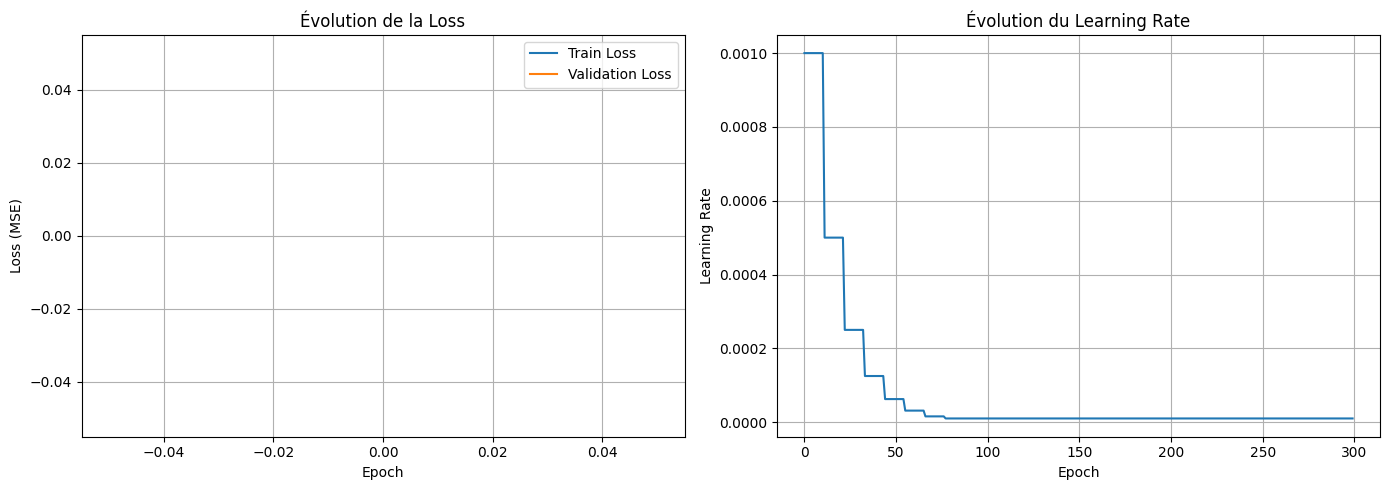

In [21]:
# Visualiser l'historique
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Évolution de la Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['learning_rate'])
plt.title('Évolution du Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# Charger le meilleur modèle
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Meilleur modèle chargé (epoch {checkpoint['epoch']+1}, val_loss: {checkpoint['val_loss']:.4f})")

Meilleur modèle chargé (epoch 191, val_loss: 238908.1625)


In [23]:
# Prédictions
model.eval()

with torch.no_grad():
    y_pred_train = model(X_train_tensor).cpu().numpy()
    y_pred_test = model(X_test_tensor).cpu().numpy()

print(f"Shape y_pred_train: {y_pred_train.shape}")
print(f"Shape y_pred_test: {y_pred_test.shape}")

Shape y_pred_train: (800, 1)
Shape y_pred_test: (200, 1)


In [24]:
# Évaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Convertir en numpy pour sklearn
y_train_np = y_train_tensor.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

# Métriques sur le test set
mse_test = mean_squared_error(y_test_np, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_np, y_pred_test)
r2_test = r2_score(y_test_np, y_pred_test)

# Métriques sur le train set
mse_train = mean_squared_error(y_train_np, y_pred_train)
r2_train = r2_score(y_train_np, y_pred_train)

print("\n" + "="*60)
print("RÉSULTATS FINAUX")
print("="*60)
print("\n--- Test Set ---")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R²:   {r2_test:.4f}")

print("\n--- Train Set ---")
print(f"MSE:  {mse_train:.4f}")
print(f"R²:   {r2_train:.4f}")
print("="*60)


RÉSULTATS FINAUX

--- Test Set ---
MSE:  260382.7969
RMSE: 510.2772
MAE:  404.6930
R²:   -0.0050

--- Train Set ---
MSE:  266930.5312
R²:   -0.0091
